In [2]:
import pandas as pd 

In [3]:
df = pd.read_csv(r'E:\SHM_ML\data\cleaned\cleaned_data.csv', index_col=0)

In [4]:
df

,f3,f5,f6,f9,f10,f11,f12,f13,tBD31A,rhBD31A,tVL,rhVL,vpVL,raVL,wsVL,wdVL
timestamp,,,,,,,,,,,,,,,,
2018-10-01 00:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,10.100000,81.000000,10.825000,89.333336,1159.144738,0.0,9.40,293.00
2018-10-01 01:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,10.000000,85.000000,10.241667,92.750000,1157.524605,0.1,10.30,295.00
2018-10-01 02:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,9.900000,91.000000,10.150000,92.000000,1141.142430,0.0,10.40,284.00
2018-10-01 03:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,9.800000,89.000000,10.166666,91.083336,1131.033604,0.3,11.60,296.00
2018-10-01 04:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,9.800000,90.000000,9.558333,93.166664,1110.625906,0.2,9.60,283.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-01-15 19:00:00,1.888801,2.555565,2.986277,4.078602,4.386448,4.942893,5.440576,6.436793,9.641429,83.304917,8.386441,83.342373,918.137648,0.0,1.96,200.08
2020-01-15 20:00:00,1.887610,2.586921,2.982070,4.080208,4.386448,4.940309,5.426145,6.398893,9.143141,80.168936,7.545000,84.875000,882.549401,0.0,1.51,187.83
2020-01-15 21:00:00,1.886253,2.581889,2.987133,4.078480,4.386448,4.908271,5.432978,6.410531,8.795149,82.076947,6.301667,89.455000,853.705976,0.0,1.07,199.95


In [5]:
df_sperate = df['2018-10-01':'2019-04-30']

In [6]:
df_sperate

,f3,f5,f6,f9,f10,f11,f12,f13,tBD31A,rhBD31A,tVL,rhVL,vpVL,raVL,wsVL,wdVL
timestamp,,,,,,,,,,,,,,,,
2018-10-01 00:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,10.100000,81.000000,10.825000,89.333336,1159.144738,0.0,9.400000,293.000000
2018-10-01 01:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,10.000000,85.000000,10.241667,92.750000,1157.524605,0.1,10.300000,295.000000
2018-10-01 02:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,9.900000,91.000000,10.150000,92.000000,1141.142430,0.0,10.400000,284.000000
2018-10-01 03:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,9.800000,89.000000,10.166666,91.083336,1131.033604,0.3,11.600000,296.000000
2018-10-01 04:00:00,1.892065,2.591636,2.919671,4.104634,4.292805,4.806421,5.324662,6.310306,9.800000,90.000000,9.558333,93.166664,1110.625906,0.2,9.600000,283.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-04-29 19:00:00,1.890049,2.594095,2.917152,4.101670,4.293515,4.813300,5.305633,6.288173,14.994566,61.665304,13.178333,67.000000,1015.313621,0.0,2.696087,314.663666
2019-04-29 20:00:00,1.895998,2.574052,2.911005,4.107677,4.293515,4.813300,5.305633,6.298710,14.102020,63.418778,12.211667,70.000000,995.619229,0.0,2.539050,319.833069
2019-04-29 21:00:00,1.890448,2.594953,2.916761,4.103926,4.293515,4.839047,5.323376,6.293116,13.356834,68.153272,11.321667,75.833336,1016.990289,0.0,2.156045,321.044067


In [7]:
freq_cols = ['f3', 'f5', 'f6', 'f9', 'f10', 'f11', 'f12', 'f13']
env_cols = ['tBD31A', 'rhBD31A', 'tVL', 'rhVL', 'vpVL', 'raVL', 'wsVL', 'wdVL']

# Training data only
x = df[env_cols].loc['2018-10-01':'2019-04-30']
y = df[freq_cols].loc['2018-10-01':'2019-04-30']

# Train one Random Forest per frequency
from sklearn.ensemble import RandomForestRegressor

models = {}
for col in freq_cols:
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(x, y[col])
    models[col] = rf

# Predict for ENTIRE dataset
predictions = {}
for col in freq_cols:
    predictions[col] = models[col].predict(df[env_cols])

pred_df = pd.DataFrame(predictions, index=df.index)

# Residuals for ENTIRE dataset
residuals_df = df[freq_cols] - pred_df

In [8]:
print(residuals_df.head())


                           f3        f5        f6        f9       f10  \
timestamp                                                               
2018-10-01 00:00:00 -0.001569  0.000602 -0.000643 -0.001125 -0.001464   
2018-10-01 01:00:00 -0.001015  0.000557 -0.000220 -0.000751 -0.000483   
2018-10-01 02:00:00 -0.000645  0.000290 -0.000222 -0.000613 -0.001403   
2018-10-01 03:00:00 -0.000786  0.000347 -0.000296 -0.000762 -0.001085   
2018-10-01 04:00:00 -0.000882  0.001238 -0.000511  0.000023 -0.000863   

                          f11       f12       f13  
timestamp                                          
2018-10-01 00:00:00 -0.012923  0.000804 -0.001559  
2018-10-01 01:00:00 -0.010297  0.000630 -0.000072  
2018-10-01 02:00:00 -0.011089  0.000354 -0.001643  
2018-10-01 03:00:00 -0.002750 -0.000367 -0.001405  
2018-10-01 04:00:00 -0.003769  0.000116 -0.000110  


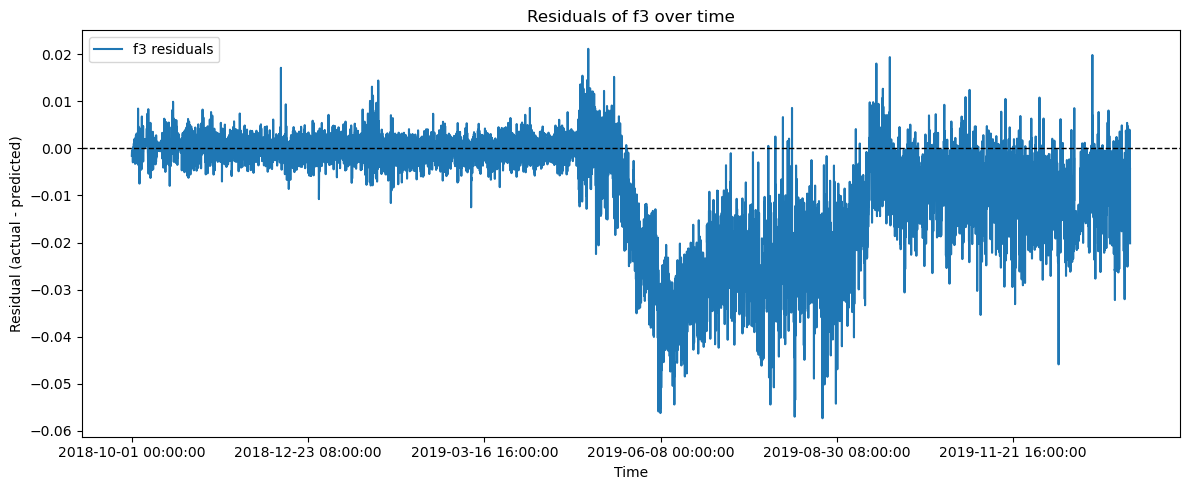

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
residuals_df['f3'].plot(label='f3 residuals')
plt.axhline(0, color='k', linestyle='--', linewidth=1)
plt.title('Residuals of f3 over time')
plt.xlabel('Time')
plt.ylabel('Residual (actual - predicted)')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# ===== 1. Imports =====
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ===== 2. Select frequency columns =====
freq_cols = ['f3','f5','f6','f9','f10','f11','f12','f13']

X_full = residuals_df[freq_cols].values
X_train = residuals_df[freq_cols].loc['2018-10-01':'2019-04-30']  # example split (change if needed)

# ===== 3. Scale data =====
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_full_scaled = scaler.transform(X_full)

# ===== 4. Build Autoencoder =====
model = Sequential([
    Dense(6, activation='relu', input_shape=(8,)),
    Dense(3, activation='relu'),
    Dense(6, activation='relu'),
    Dense(8, activation='linear')
])

# ===== 5. Compile =====
model.compile(optimizer='adam', loss='mse')

# ===== 6. Train =====
model.fit(
    X_train_scaled,
    X_train_scaled,
    epochs=50,
    batch_size=32
)

# ===== 7. Reconstruction =====
reconstructed = model.predict(X_full_scaled)

# ===== 8. Residuals and error =====
residuals = X_full_scaled - reconstructed
mse = np.mean(residuals**2, axis=1)

Epoch 1/50


c:\Users\forla\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\forla\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.9955
Epoch 2/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9050
Epoch 3/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7958
Epoch 4/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7013
Epoch 5/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6354
Epoch 6/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5918
Epoch 7/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5627
Epoch 8/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5434
Epoch 9/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5307
Epoch 10/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5215
Epoch 11/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5151
Epoch 12/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5100
Epoch 13/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5060
Epoch 14/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5021
Epoch 15/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4989


In [11]:
residuals_df.shape 

(11328, 8)

In [12]:
import pandas as pd

mse_series = pd.Series(mse, index=residuals_df.index)
print(mse_series.describe())

count    11328.000000
mean       497.771641
std        817.480101
min          0.001559
25%          0.353582
50%        180.118697
75%        283.250176
max       3171.347888
dtype: float64


In [13]:
train_mse = mse_series['2018-10-01':'2019-04-30']
threshold = train_mse.mean() + 3 * train_mse.std()
print(threshold)

2.1296890164734776


In [14]:
mse_series = pd.Series(mse, index=residuals_df.index)

In [15]:
anomalies = mse_series[mse_series > threshold]
print(f"Total anomalies flagged: {len(anomalies)}")
print(f"Percentage of data flagged: {len(anomalies)/len(mse_series)*100:.2f}%")

Total anomalies flagged: 6236
Percentage of data flagged: 55.05%


In [16]:
print(train_mse.describe())


count    5064.000000
mean        0.460262
std         0.556476
min         0.001559
25%         0.169029
50%         0.312665
75%         0.557478
max         7.323893
dtype: float64


In [17]:
print(X_train_scaled.mean())
print(X_train_scaled.std())

9.997268942122263e-18
1.0


In [18]:

print(residuals_df.loc['2018-10-01':'2019-04-30'].describe())

                f3           f5           f6           f9          f10  \
count  5064.000000  5064.000000  5064.000000  5064.000000  5064.000000   
mean      0.000012    -0.000024    -0.000024    -0.000006    -0.000023   
std       0.002371     0.005502     0.001804     0.001394     0.003845   
min      -0.012520    -0.024703    -0.009245    -0.008213    -0.019934   
25%      -0.001391    -0.003221    -0.001079    -0.000856    -0.002310   
50%       0.000062    -0.000022    -0.000057    -0.000021    -0.000204   
75%       0.001379     0.003214     0.001003     0.000851     0.002251   
max       0.017106     0.024996     0.013693     0.009259     0.021366   

               f11          f12          f13  
count  5064.000000  5064.000000  5064.000000  
mean      0.000037     0.000036    -0.000048  
std       0.011261     0.005566     0.006935  
min      -0.058144    -0.039835    -0.059360  
25%      -0.006557    -0.002590    -0.003257  
50%      -0.000335    -0.000011    -0.000166  
75% 

In [19]:
# ===== 1. Clip residuals at 3 std (calculated from training period only) =====
train_period = residuals_df.loc['2018-10-01':'2019-04-30']
train_mean = train_period.mean()
train_std = train_period.std()

lower = train_mean - 3 * train_std
upper = train_mean + 3 * train_std

residuals_clipped = residuals_df.clip(lower=lower, upper=upper, axis=1)

# ===== 2. Prepare data =====
X_full = residuals_clipped.values
X_train = residuals_clipped.loc['2018-10-01':'2019-04-30'].values

# ===== 3. Scale =====
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_full_scaled = scaler.transform(X_full)

# ===== 4. Build autoencoder =====
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(6, activation='relu', input_shape=(8,)),
    Dense(3, activation='relu'),
    Dense(6, activation='relu'),
    Dense(8, activation='linear')
])

model.compile(optimizer='adam', loss='mse')

# ===== 5. Train =====
history = model.fit(
    X_train_scaled, X_train_scaled,
    epochs=100,
    batch_size=32,
    verbose=1
)

# ===== 6. Reconstruct and compute MSE =====
reconstructed = model.predict(X_full_scaled)
mse = np.mean((X_full_scaled - reconstructed)**2, axis=1)

# ===== 7. MSE series =====
import pandas as pd
mse_series = pd.Series(mse, index=residuals_clipped.index)

# ===== 8. Threshold from training period =====
train_mse = mse_series['2018-10-01':'2019-04-30']
threshold = train_mse.mean() + 3 * train_mse.std()
print(f"Threshold: {threshold:.4f}")

# ===== 9. Flag anomalies =====
anomalies = mse_series[mse_series > threshold]
print(f"Total anomalies flagged: {len(anomalies)}")
print(f"Percentage flagged: {len(anomalies)/len(mse_series)*100:.2f}%")

# ===== 10. Final epoch loss =====
print(f"Final training loss: {history.history['loss'][-1]:.4f}")

Epoch 1/100


c:\Users\forla\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.9962
Epoch 2/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8830
Epoch 3/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7858
Epoch 4/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7273
Epoch 5/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6883
Epoch 6/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6539
Epoch 7/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6152
Epoch 8/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.5727
Epoch 9/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5470
Epoch 10/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5320
Epoch 11/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5221
Epoch 12/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5145
Epoch 13/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5084
Epoch 14/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5034
Epoch 15/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step -

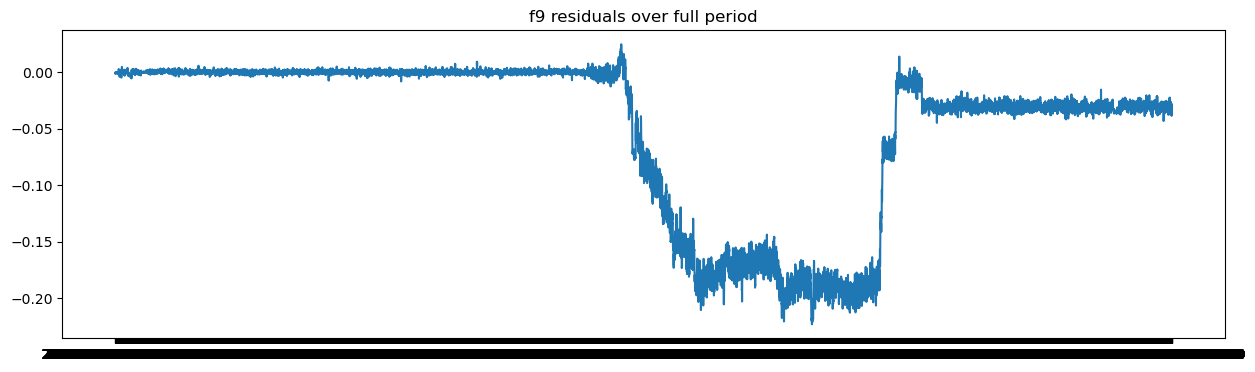

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,4))
plt.plot(residuals_df.index, residuals_df['f9'])
plt.title('f9 residuals over full period')
plt.show()

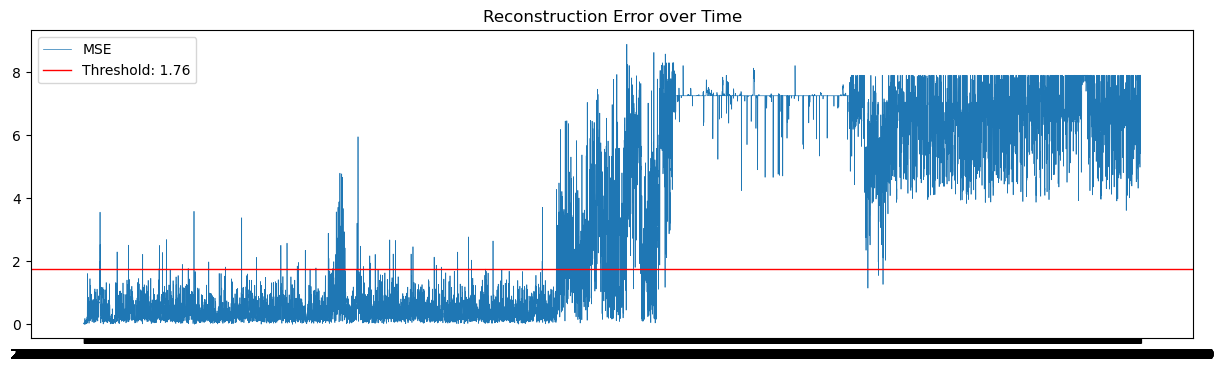

In [21]:
plt.figure(figsize=(15,4))
plt.plot(mse_series.index, mse_series.values, linewidth=0.5, label='MSE')
plt.axhline(y=threshold, color='red', linewidth=1, label=f'Threshold: {threshold:.2f}')
plt.title('Reconstruction Error over Time')
plt.legend()
plt.show()

In [22]:
# Find where anomalies start and end
print(anomalies.index[0])
print(anomalies.index[-1])

2018-10-08 01:00:00
2020-01-15 23:00:00


In [23]:
# Find where MSE stays above threshold for more than 24 consecutive hours
above = mse_series > threshold
sustained = above.rolling(24).sum() == 24
print(sustained[sustained].index[0])

2019-05-16 18:00:00


In [24]:
after_start = mse_series['2019-05-16':]
recovery = after_start < threshold
if recovery.any():
    print(recovery[recovery].index[0])

2019-05-17 06:00:00


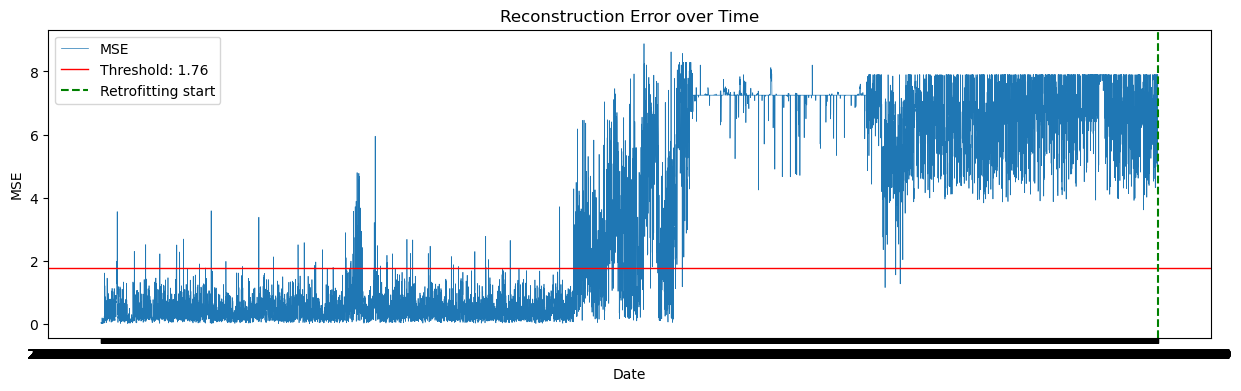

In [25]:
plt.figure(figsize=(15,4))
plt.plot(mse_series.index, mse_series.values, linewidth=0.5, label='MSE')
plt.axhline(y=threshold, color='red', linewidth=1, label=f'Threshold: {threshold:.2f}')
plt.axvline(x='2019-05-16', color='green', linewidth=1.5, linestyle='--', label='Retrofitting start')
plt.title('Reconstruction Error over Time')
plt.xlabel('Date')
plt.ylabel('MSE')
plt.legend()
plt.show()

ConversionError: Failed to convert value(s) to axis units: Timestamp('2019-05-16 00:00:00')

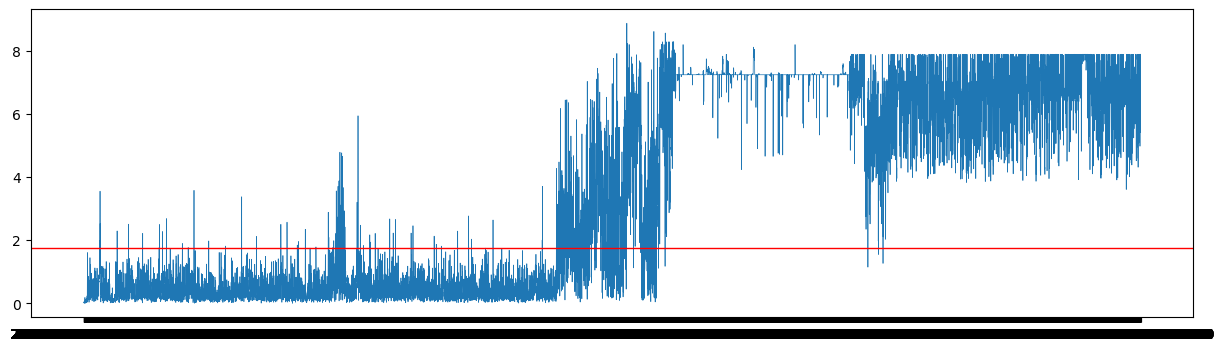

In [26]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(15,4))
ax.plot(mse_series.index, mse_series.values, linewidth=0.5, label='MSE')
ax.axhline(y=threshold, color='red', linewidth=1, label=f'Threshold: {threshold:.2f}')
ax.axvline(x=pd.Timestamp('2019-05-16'), color='green', linewidth=1.5, linestyle='--', label='Retrofitting start')
ax.set_title('Reconstruction Error over Time')
ax.set_xlabel('Date')
ax.set_ylabel('MSE')
ax.legend()
plt.show()